# Environment Setup and Stream Loading

In [15]:
import os
import json
import re
import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:

SAMPLE_SIZE = 5000  
DATA_FILE = 'arxiv-metadata-oai-snapshot.json'


if not os.path.exists(DATA_FILE):

    os.environ['KAGGLE_USERNAME'] = "guojietao"
    os.environ['KAGGLE_KEY'] = "KGAT_847fa7483d5e26315ee7960bd54719f5"
    
    !mkdir -p ~/.kaggle
    !echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    

    !kaggle datasets download -d Cornell-University/arxiv
    !unzip -o arxiv.zip


raw_abstracts_dict = {}

with open(DATA_FILE, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
            
        paper_data = json.loads(line)
        

        raw_abstracts_dict[paper_data['id']] = paper_data['abstract'].strip()

print(f"Total papers loaded into memory: {len(raw_abstracts_dict)}")

Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
100%|█████████████████████████████████████| 1.65G/1.65G [01:40<00:00, 17.6MB/s]

Archive:  arxiv.zip
  inflating: arxiv-metadata-oai-snapshot.json  
Total papers loaded into memory: 5000


# Text Cleaning and Hash Shingling

In [ ]:

K_SHINGLE = 5


doc_shingles_dict = {}

for paper_id, abstract in raw_abstracts_dict.items():

    clean_text = re.sub(r'[^\w\s]', ' ', abstract.lower())
    words = clean_text.split()
    
    shingles_set = set()

    for i in range(len(words) - K_SHINGLE + 1):
        shingle_string = " ".join(words[i : i + K_SHINGLE])
        shingles_set.add(hash(shingle_string))
        
    doc_shingles_dict[paper_id] = shingles_set

first_id = list(doc_shingles_dict.keys())[0]
print(f"Sample paper ID: {first_id}")
print(f"Number of generated hash shingles: {len(doc_shingles_dict[first_id])}")

Sample paper ID: 0704.0001
Number of generated hash shingles: 148


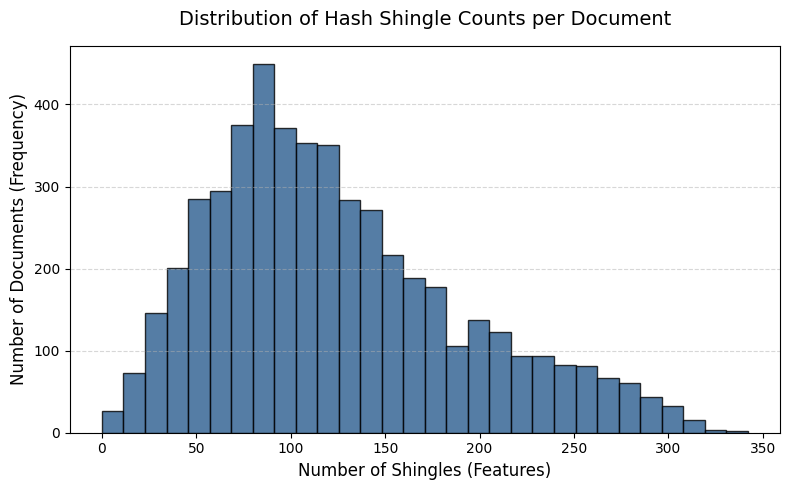

In [12]:
shingle_counts = [len(shingles) for shingles in doc_shingles_dict.values()]


plt.figure(figsize=(8, 5))
plt.hist(shingle_counts, bins=30, color='#2b5c8f', edgecolor='black', alpha=0.8)


plt.title('Distribution of Hash Shingle Counts per Document', fontsize=14, pad=15)
plt.xlabel('Number of Shingles (Features)', fontsize=12)
plt.ylabel('Number of Documents (Frequency)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

# Min-Hashing Signature Matrix Generation

In [14]:
NUM_HASHES = 100


paper_ids = list(doc_shingles_dict.keys())
num_docs = len(paper_ids)


PRIME_C = 424243


random.seed(42)
A = [random.randint(1, PRIME_C - 1) for _ in range(NUM_HASHES)]
B = [random.randint(0, PRIME_C - 1) for _ in range(NUM_HASHES)]


signature_matrix = np.full((NUM_HASHES, num_docs), float('inf'))


for doc_idx, pid in enumerate(paper_ids):
    shingles = doc_shingles_dict[pid]
    
    for x in shingles:
        for h_idx in range(NUM_HASHES):

            hash_val = (A[h_idx] * x + B[h_idx]) % PRIME_C
            

            if hash_val < signature_matrix[h_idx, doc_idx]:
                signature_matrix[h_idx, doc_idx] = hash_val


print(f"Signature Matrix shape: {signature_matrix.shape}")

Signature Matrix shape: (100, 5000)


# Locality-Sensitive Hashing

In [16]:
B_BANDS = 20
R_ROWS = 5


num_hashes, num_docs = signature_matrix.shape
buckets = defaultdict(list)


for b_idx in range(B_BANDS):
    start_row = b_idx * R_ROWS
    end_row = start_row + R_ROWS
    

    for doc_idx in range(num_docs):
        band_signature = tuple(signature_matrix[start_row:end_row, doc_idx])
        
        bucket_key = (b_idx, band_signature)
        
        buckets[bucket_key].append(paper_ids[doc_idx])

candidate_pairs = set()
for doc_list in buckets.values():
    if len(doc_list) > 1:
        for i in range(len(doc_list)):
            for j in range(i + 1, len(doc_list)):
                pair = tuple(sorted([doc_list[i], doc_list[j]]))
                candidate_pairs.add(pair)

print(f"Number of generated candidate pairs via LSH: {len(candidate_pairs)}")

Number of generated candidate pairs via LSH: 10


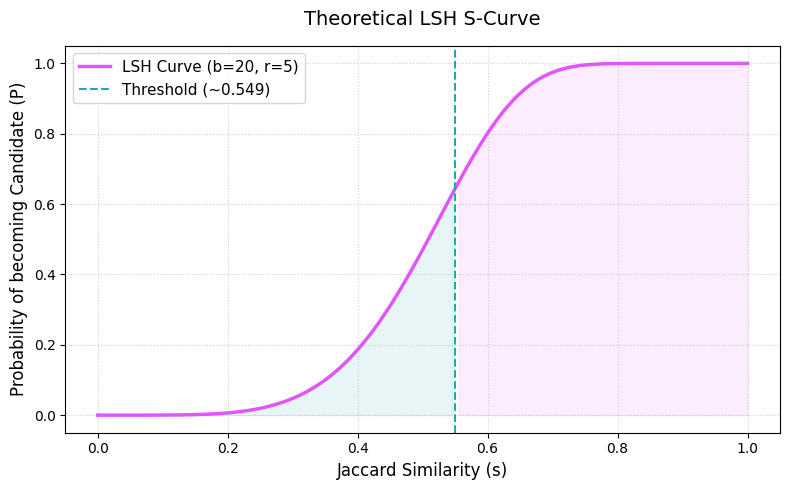

In [17]:

s_values = np.linspace(0, 1, 100)
p_values = 1 - (1 - s_values ** R_ROWS) ** B_BANDS

threshold = (1 / B_BANDS) ** (1 / R_ROWS)

plt.figure(figsize=(8, 5))
plt.plot(s_values, p_values, color='#e056fd', linewidth=2.5, label=f'LSH Curve (b={B_BANDS}, r={R_ROWS})')
plt.axvline(x=threshold, color='#22a6b3', linestyle='--', linewidth=1.5, label=f'Threshold (~{threshold:.3f})')

plt.fill_between(s_values, p_values, where=(s_values < threshold), color='#22a6b3', alpha=0.1)
plt.fill_between(s_values, p_values, where=(s_values >= threshold), color='#e056fd', alpha=0.1)

plt.title('Theoretical LSH S-Curve', fontsize=14, pad=15)
plt.xlabel('Jaccard Similarity (s)', fontsize=12)
plt.ylabel('Probability of becoming Candidate (P)', fontsize=12)
plt.grid(linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# Jaccard Similarity Verification and Results

In [21]:

SIM_THRESHOLD = 0.5


verified_pairs = []
verified_scores = []

for doc_a, doc_b in candidate_pairs:
    shingles_a = doc_shingles_dict[doc_a]
    shingles_b = doc_shingles_dict[doc_b]
    
    intersection = len(shingles_a.intersection(shingles_b))
    union = len(shingles_a.union(shingles_b))
    
    jaccard_sim = intersection / union if union > 0 else 0
    
    if jaccard_sim >= SIM_THRESHOLD:
        verified_pairs.append((doc_a, doc_b))
        verified_scores.append(jaccard_sim)

print(f"Total verified highly similar paper pairs: {len(verified_pairs)}")


Total verified highly similar paper pairs: 9
